# Summary Shapley Explainer Demo

This example demonstrates how to interpret a **scikit-learn** model using
the H2O Sonar library and retrieve the data and plot the **summary Shapley**.

In [1]:
import logging

import pandas
import webbrowser

from h2o_sonar import interpret
from h2o_sonar.lib.api import commons
from h2o_sonar.lib.api import explainers
from h2o_sonar.lib.api.models import ModelApi
from h2o_sonar.explainers.summary_shap_explainer import SummaryShapleyExplainer

from sklearn.ensemble import GradientBoostingClassifier

In [2]:
results_location = "../../results"

# dataset
dataset_path = "../../data/predictive/creditcard.csv"
target_col = "default payment next month"
df = pandas.read_csv(dataset_path)
(X, y) = df.drop(target_col, axis=1), df[target_col]

In [3]:
# parameters
interpret.describe_explainer(SummaryShapleyExplainer)

{'id': 'h2o_sonar.explainers.summary_shap_explainer.SummaryShapleyExplainer',
 'name': 'SummaryShapleyExplainer',
 'display_name': 'Shapley Summary Plot for Original Features (Kernel SHAP Method)',
 'tagline': 'SummaryShapleyExplainer.',
 'description': 'Shapley explanations are a technique with credible theoretical support that presents consistent global and local feature contributions.\n\nThe Shapley Summary Plot shows original features versus their local Shapley values on a sample of the dataset. Feature values are binned by Shapley values and the average normalized feature value for each bin is plotted. The legend corresponds to numeric features and maps to their normalized value - yellow is the lowest value and deep orange is the highest. You can also get a scatter plot of the actual numeric features values versus their corresponding Shapley values. Categorical features are shown in grey and do not provide an actual-value scatter plot.\n\nNotes:\n\n* The Shapley Summary Plot only 

## Interpretation

In [4]:
# scikit-learn model
gradient_booster = GradientBoostingClassifier(learning_rate=0.1)
gradient_booster.fit(X, y)

# explainable model
explainable_model = ModelApi().create_model(
    target_col=target_col,
    model_src=gradient_booster,
    used_features=X.columns.to_list()
)

interpretation = interpret.run_interpretation(
    dataset=df,
    model=explainable_model,
    target_col=target_col,
    results_location=results_location,
    log_level=logging.INFO,
    explainers=[
        commons.ExplainerToRun(
            explainer_id=SummaryShapleyExplainer.explainer_id(),
            params="",
        )
    ]
)

As of langchain-core 0.3.0, LangChain uses pydantic v2 internally. The langchain_core.pydantic_v1 module was a compatibility shim for pydantic v1, and should no longer be used. Please update the code to import from Pydantic directly.

For example, replace imports like: `from langchain_core.pydantic_v1 import BaseModel`
with: `from pydantic import BaseModel`
or the v1 compatibility namespace if you are working in a code base that has not been fully upgraded to pydantic 2 yet. 	from pydantic.v1 import BaseModel

As of langchain-core 0.3.0, LangChain uses pydantic v2 internally. The langchain.pydantic_v1 module was a compatibility shim for pydantic v1, and should no longer be used. Please update the code to import from Pydantic directly.

For example, replace imports like: `from langchain.pydantic_v1 import BaseModel`
with: `from pydantic import BaseModel`
or the v1 compatibility namespace if you are working in a code base that has not been fully upgraded to pydantic 2 yet. 	from pydantic

## Interact with the Explainer Result

In [5]:
# retrieve the result
result = interpretation.get_explainer_result(SummaryShapleyExplainer.explainer_id())

In [6]:
# open interpretation HTML report in web browser
webbrowser.open(interpretation.result.get_html_report_location())

True

In [7]:
# summary
result.summary()

{'id': 'h2o_sonar.explainers.summary_shap_explainer.SummaryShapleyExplainer',
 'name': 'SummaryShapleyExplainer',
 'display_name': 'Shapley Summary Plot for Original Features (Kernel SHAP Method)',
 'tagline': 'SummaryShapleyExplainer.',
 'description': 'Shapley explanations are a technique with credible theoretical support that presents consistent global and local feature contributions.\n\nThe Shapley Summary Plot shows original features versus their local Shapley values on a sample of the dataset. Feature values are binned by Shapley values and the average normalized feature value for each bin is plotted. The legend corresponds to numeric features and maps to their normalized value - yellow is the lowest value and deep orange is the highest. You can also get a scatter plot of the actual numeric features values versus their corresponding Shapley values. Categorical features are shown in grey and do not provide an actual-value scatter plot.\n\nNotes:\n\n* The Shapley Summary Plot only 

In [8]:
# parameters
result.params()

{'max_features': 50,
 'sample_size': 20000,
 'x_shapley_resolution': 500,
 'enable_drilldown_charts': True,
 'fast_approx_contribs': True}

### Display the Shapley Shapley

In [9]:
# get the data for all features
result.data()

,MARRIAGE,BILL_AMT2,AGE,PAY_0,PAY_AMT3,EDUCATION,BILL_AMT3,BILL_AMT5,PAY_AMT5,LIMIT_BAL,…,PAY_AMT6,PAY_4,BILL_AMT6,PAY_AMT1,bias
,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪
0,1.66392,0.754229,0.525014,−0.0769926,0.343486,0.459352,0.173675,0.0163271,−0.00919648,−0.0213322,…,−0.0672808,0.0943492,−0.106023,0.010494,−1.44588
1,1.75075,0.365596,0.311988,−0.224273,−0.119805,0.0425741,0.141538,0.26145,−0.00507203,0.00920574,…,−0.0162608,0.0213093,0.00764593,0.00946223,−1.44588
2,1.79185,0.379105,0.25219,−0.257663,−0.144234,0.0711456,0.153144,0.190386,0.207591,−0.0191975,…,−0.0408922,0.0126469,0.00341155,−0.0158366,−1.44588
3,1.79185,0.34528,0.252297,−0.257663,−0.144234,0.0711456,0.169791,0.190446,0.207591,−0.0191975,…,−0.0408922,0.0126469,0.00432853,−0.0168906,−1.44588
4,1.79242,0.433088,0.248932,−0.23324,−0.128322,0.0711456,0.153144,0.181755,0.207591,−0.0193396,…,−0.0163037,0.0126469,0.00780872,−0.0122551,−1.44588
5,1.79185,0.379105,0.25219,−0.257663,−0.144234,0.0711456,0.153144,0.190386,0.207591,−0.0191975,…,−0.0408922,0.0126469,0.00341155,−0.0158366,−1.44588
6,1.84325,0.378151,0.149483,−0.17116,−0.144735,0.11591,0.0972286,−0.263704,0.197469,0.18672,…,−0.0407482,0.0126469,0.0289509,−0.089523,−1.44588
7,1.7705,0.430811,0.304604,−0.236441,0.345056,0.363289,0.139994,−0.0422748,0.130124,0.00971828,…,−0.0124586,0.0943492,0.0151488,−0.0012627,−1.44588
8,1.78661,0.380776,0.321885,−0.23324,−0.128322,0.105382,0.153144,0.153698,0.187062,0.0740197,…,−0.0163037,0.0126469,0.00461817,−0.00961812,−1.44588


In [10]:
# get the data for only feature "PAY_0"
result.data(feature_names="PAY_0")

,PAY_0,bias
,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪
0,−0.0769926,−1.44588
1,−0.224273,−1.44588
2,−0.257663,−1.44588
3,−0.257663,−1.44588
4,−0.23324,−1.44588
5,−0.257663,−1.44588
6,−0.17116,−1.44588
7,−0.236441,−1.44588
8,−0.23324,−1.44588


In [11]:
# get the data for "PAY_0", "AGE and "EDUCATION"
result.data(feature_names=["PAY_0", "AGE", "EDUCATION"])

,PAY_0,AGE,EDUCATION,bias
,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪,▪▪▪▪▪▪▪▪
0,−0.0769926,0.525014,0.459352,−1.44588
1,−0.224273,0.311988,0.0425741,−1.44588
2,−0.257663,0.25219,0.0711456,−1.44588
3,−0.257663,0.252297,0.0711456,−1.44588
4,−0.23324,0.248932,0.0711456,−1.44588
5,−0.257663,0.25219,0.0711456,−1.44588
6,−0.17116,0.149483,0.11591,−1.44588
7,−0.236441,0.304604,0.363289,−1.44588
8,−0.23324,0.321885,0.105382,−1.44588


### Plot the Summary Shapley

invalid value encountered in divide


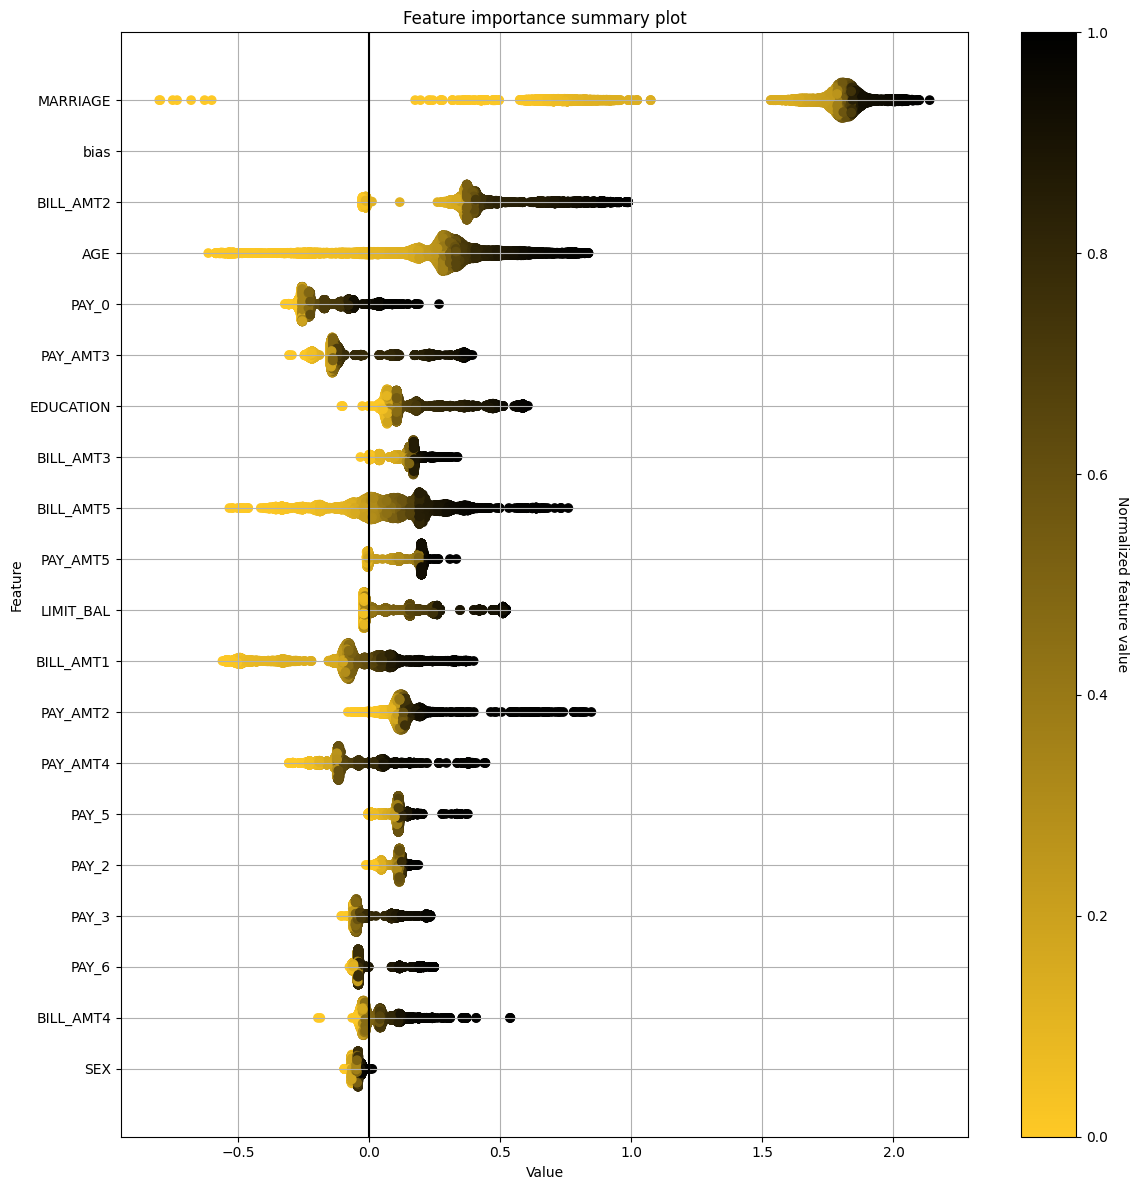

In [12]:
# plot summary shap for all features
result.plot()

invalid value encountered in divide


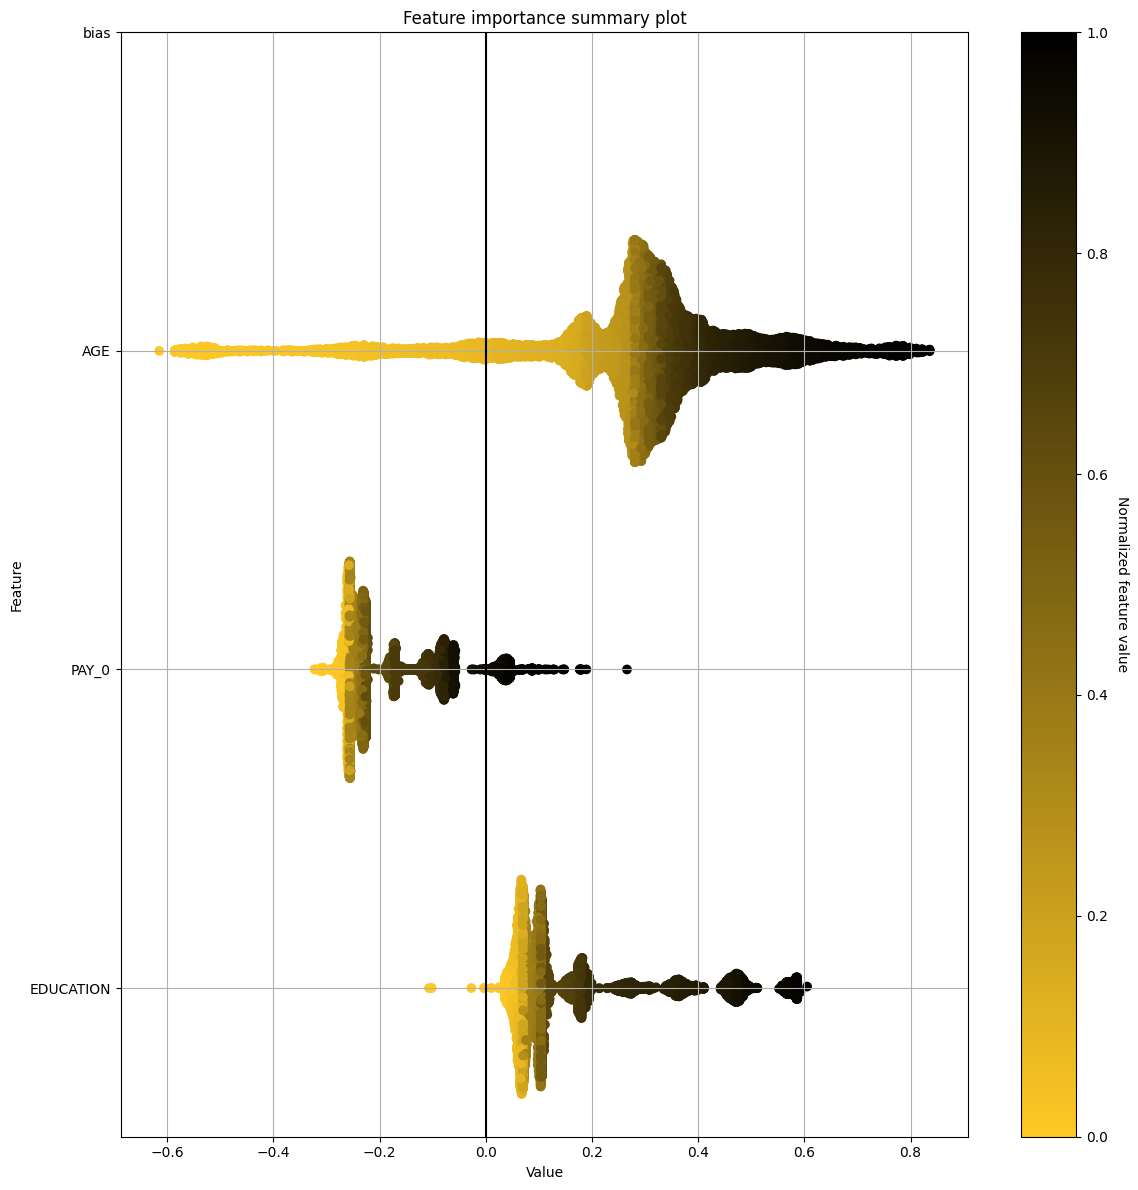

In [13]:
# plot summary shap for "PAY_0", "AGE and "EDUCATION"
result.plot(feature_names=["PAY_0", "AGE", "EDUCATION"])

### Save the explainer log and data

In [14]:
# save the explainer log
result.log(path="./summary-shapley-demo.log")

In [15]:
!head summary-shapley-demo.log

2026-01-29 16:28:24,384 INFO Summary Shapley explainer b33e9469-d080-404e-891c-4e2159d64a4c/a1b410cf-2b5d-473a-8295-ec5310f7277f raw MEANs (1)
2026-01-29 16:28:24,384 INFO Summary Shapley explainer b33e9469-d080-404e-891c-4e2159d64a4c/a1b410cf-2b5d-473a-8295-ec5310f7277f raw CONTRIBs (1)


In [16]:
# save the explainer data
result.zip(file_path="./summary-shapley-demo-archive.zip")

In [17]:
!unzip -l summary-shapley-demo-archive.zip

Archive:  summary-shapley-demo-archive.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
     4129  2026-01-29 16:28   explainer_h2o_sonar_explainers_summary_shap_explainer_SummaryShapleyExplainer_a1b410cf-2b5d-473a-8295-ec5310f7277f/result_descriptor.json
        2  2026-01-29 16:28   explainer_h2o_sonar_explainers_summary_shap_explainer_SummaryShapleyExplainer_a1b410cf-2b5d-473a-8295-ec5310f7277f/problems/problems_and_actions.json
      110  2026-01-29 16:28   explainer_h2o_sonar_explainers_summary_shap_explainer_SummaryShapleyExplainer_a1b410cf-2b5d-473a-8295-ec5310f7277f/global_html_fragment/text_html.meta
   142756  2026-01-29 16:28   explainer_h2o_sonar_explainers_summary_shap_explainer_SummaryShapleyExplainer_a1b410cf-2b5d-473a-8295-ec5310f7277f/global_html_fragment/text_html/feature_1_class_0.png
    95488  2026-01-29 16:28   explainer_h2o_sonar_explainers_summary_shap_explainer_SummaryShapleyExplainer_a1b410cf-2b5d-473a-8295-ec5310f7277f/global_html_fra